In [8]:
!pip install ruptures

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.3.1 -> 24.2
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip


In [9]:
import yfinance as yf
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import ruptures as rpt
import matplotlib.pyplot as plt
from scipy.stats import entropy

# CUSUM breakpoints

[*********************100%***********************]  1 of 1 completed


Structural Break
0    2000
1      11
Name: count, dtype: int64


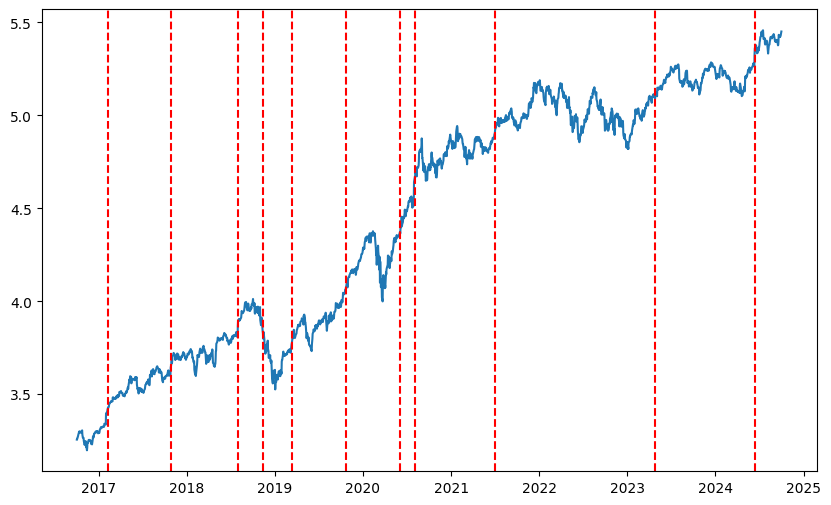

In [10]:
def apply_cusum(series, threshold=0.03):
    """Simple CUSUM implementation for detecting structural breaks."""
    mean_value = series.mean()
    cumulative_sum = 0
    cusum_signal = []
    for price in series:
        cumulative_sum += price - mean_value
        if abs(cumulative_sum) > threshold:
            cusum_signal.append(1)
            cumulative_sum = 0  # Reset signal
        else:
            cusum_signal.append(0)
    return cusum_signal

# fetch data
ticker_symbol = "AAPL"
start_date = "2016-10-01"
end_date = "2024-10-01"
stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)

stock_data['Log Stock Price'] = np.log(stock_data['Adj Close'])
stock_data['Log Returns'] = stock_data['Log Stock Price'].diff()

# Apply CUSUM to detect structural breaks
cusum_feature = apply_cusum(stock_data['Log Returns'].dropna(), threshold=0.03)  # Adjusted threshold maybe

stock_data['CUSUM Feature'] = pd.Series(cusum_feature, index=stock_data['Log Returns'].dropna().index)

# Reindex CUSUM feature
stock_data['CUSUM Feature'] = stock_data['CUSUM Feature'].reindex(stock_data.index, fill_value=0)

# Detect Structural Breaks using Ruptures
model = "l2"  # Least-squares method
algo = rpt.Pelt(model=model).fit(stock_data['Log Stock Price'].dropna().values)

### Use a lower penalty to detect more breakpoints
breakpoints = algo.predict(pen=1)

# Remove the last breakpoint
breakpoints = breakpoints[:-1]

stock_data['Structural Break'] = 0

# Mark the detected breakpoints
stock_data.iloc[breakpoints, stock_data.columns.get_loc('Structural Break')] = 1

print(stock_data['Structural Break'].value_counts())

plt.figure(figsize=(10, 6))
plt.plot(stock_data['Log Stock Price'], label="Log Stock Price")
for bp in breakpoints:
    plt.axvline(x=stock_data.index[bp], color='red', linestyle='--', label='Break Point')
plt.show()

In [11]:
# different penalty values
for pen_value in [0.5, 1, 2, 3, 4]:
    algo = rpt.Pelt(model="l2").fit(stock_data['Log Stock Price'].dropna().values)
    breakpoints = algo.predict(pen=pen_value)
    print(f"Breakpoints for penalty {pen_value}: {breakpoints}")

Breakpoints for penalty 0.5: [90, 270, 460, 535, 615, 735, 780, 920, 965, 1050, 1195, 1295, 1410, 1635, 1935, 2011]
Breakpoints for penalty 1: [90, 270, 460, 535, 615, 770, 920, 965, 1195, 1650, 1935, 2011]
Breakpoints for penalty 2: [100, 400, 760, 915, 965, 1195, 1650, 1935, 2011]
Breakpoints for penalty 3: [100, 400, 765, 945, 1195, 1660, 2011]
Breakpoints for penalty 4: [100, 400, 765, 945, 1195, 1660, 2011]


In [12]:
# different models
for model in ["l2", "l1", "rbf"]:
    algo = rpt.Pelt(model=model).fit(stock_data['Log Stock Price'].dropna().values)
    breakpoints = algo.predict(pen=3)  # Keeping the same penalty for comparison
    print(f"Breakpoints for model {model}: {breakpoints}")

Breakpoints for model l2: [100, 400, 765, 945, 1195, 1660, 2011]
Breakpoints for model l1: [85, 145, 270, 400, 460, 535, 615, 760, 810, 925, 965, 1050, 1195, 1295, 1400, 1645, 1935, 2011]
Breakpoints for model rbf: [90, 270, 460, 535, 615, 770, 920, 965, 1195, 1650, 1935, 2011]


In [13]:
def rolling_sadf(series, window=60):
    sadf_values = []
    for i in range(len(series) - window + 1):
        sub_series = series.iloc[i:i + window]
        result = adfuller(sub_series)
        sadf_values.append(result[0])  # ADF statistic
    # Return NaNs for first (window - 1) values, followed by SADF values
    return [np.nan] * (window - 1) + sadf_values

# Apply rolling SADF test for bubbles or explosive moves
window_size = 60
sadf_values = rolling_sadf(stock_data['Log Stock Price'].dropna(), window=window_size)

# Reindex SADF to align with the original stock_data
stock_data['SADF Feature'] = pd.Series(sadf_values, index=stock_data['Log Stock Price'].dropna().index)

In [14]:
stock_data[['Log Stock Price', 'Log Returns', 'SADF Feature', 'CUSUM Feature', 'Structural Break']].tail(20)

,Log Stock Price,Log Returns,SADF Feature,CUSUM Feature,Structural Break
Date,,,,,
2024-09-03,5.406140,-0.027582,-2.905236,0.0,0
2024-09-04,5.397484,-0.008656,-3.830359,1.0,0
2024-09-05,5.404388,0.006904,-2.262782,0.0,0
2024-09-06,5.397348,-0.007040,-1.909594,0.0,0
2024-09-09,5.397755,0.000407,-1.880344,0.0,0
2024-09-10,5.394127,-0.003628,-1.983743,0.0,0
2024-09-11,5.405646,0.011519,-1.811881,0.0,0
2024-09-12,5.406140,0.000494,-1.903205,0.0,0
2024-09-13,5.404927,-0.001213,-2.207914,0.0,0


### The Corwin and Schultz

In [48]:
import pandas as pd
import numpy as np

# Existing functions from your provided code (adjust as needed for newer pandas versions)
def getBeta(series, sl):
    hl = series[['High', 'Low']].values
    hl = np.log(hl[:, 0] / hl[:, 1]) ** 2
    hl = pd.Series(hl, index=series.index)
    beta = hl.rolling(window=2).sum()
    beta = beta.rolling(window=sl).mean()
    return beta.dropna()

def getGamma(series):
    h2 = series['High'].rolling(window=2).max()
    l2 = series['Low'].rolling(window=2).min()
    gamma = np.log(h2.values / l2.values) ** 2
    gamma = pd.Series(gamma, index=h2.index)
    return gamma.dropna()

def getAlpha(beta, gamma):
    den = 3 - 2 * 2 ** 0.5
    alpha = (2 ** 0.5 - 1) * (beta ** 0.5) / den
    alpha = -(gamma / den) ** 0.5
    # alpha[alpha < 0] = 0  # set negative alphas to 0
    return alpha.dropna()

def corwinSchultz(series, sl=1):
    beta = getBeta(series, sl)
    gamma = getGamma(series)
    alpha = getAlpha(beta, gamma)
    spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))
    startTime = pd.Series(series.index[0:spread.shape[0]], index=spread.index)
    spread = pd.concat([spread, startTime], axis=1)
    spread.columns = ['Spread', 'Start_Time']
    return spread

# Run the Corwin-Schultz estimator on the data
spread_data = corwinSchultz(stock_data)
spread_data

,Spread,Start_Time
Date,,
2016-10-04,-0.043252,2016-10-03
2016-10-05,-0.035741,2016-10-04
2016-10-06,-0.035089,2016-10-05
2016-10-07,-0.030323,2016-10-06
2016-10-10,-0.067919,2016-10-07
...,...,...
2024-09-24,-0.039457,2024-09-23
2024-09-25,-0.056752,2024-09-24
2024-09-26,-0.047794,2024-09-25


## VPIN

In [52]:
# Step 1: Classify trades (Tick Test Method)
def classify_trades(mid_price_series):
    price_diff = mid_price_series.diff()
    trade_sign = np.sign(price_diff).fillna(0)  # 1 for buy, -1 for sell
    trade_sign[trade_sign == 0] = trade_sign.shift(1)  # Carry forward no-change signals
    return trade_sign

stock_data['trade_sign'] = classify_trades(stock_data['MidPrice'])

# Step 2: Aggregate trades into volume bars
def get_volume_bars(df, volume_threshold):
    df['Cum_Volume'] = df['Volume'].cumsum()  # Cumulative volume
    bar_index = np.floor(df['Cum_Volume'] / volume_threshold)
    
    # Aggregating into volume bars
    volume_bars = df.groupby(bar_index).agg({
        'Volume': 'sum',  # Total volume for the bar
        'Log Returns': 'sum',  # Summed returns
        'Log Stock Price': 'last',  # Last price in the bar
        'trade_sign': 'sum'  # Total buy/sell imbalance in the bar
    })
    return volume_bars

# Set the volume threshold (e.g., 100 million shares)
volume_threshold = 100000000

volume_bars = get_volume_bars(stock_data, volume_threshold)

# Step 3: Compute VPIN
def compute_vpin(volume_bars, window):
    order_imbalance = np.abs(volume_bars['trade_sign'])  # Absolute imbalance
    total_volume = volume_bars['Volume']
    vpin = order_imbalance.rolling(window).mean() / total_volume.rolling(window).mean()
    return vpin

# Define rolling window for VPIN calculation
window = 2  # Example, you can adjust this based on your dataset

vpin_series = compute_vpin(volume_bars, window)

# Display the results
print(vpin_series)

Cum_Volume
0.0                NaN
2.0       0.000000e+00
4.0       3.126204e-09
5.0       9.409515e-09
6.0       8.251588e-09
              ...     
2082.0    8.637335e-09
2085.0    6.736183e-09
2086.0    7.204922e-09
2087.0    1.132198e-08
2088.0    1.193935e-08
Length: 1670, dtype: float64


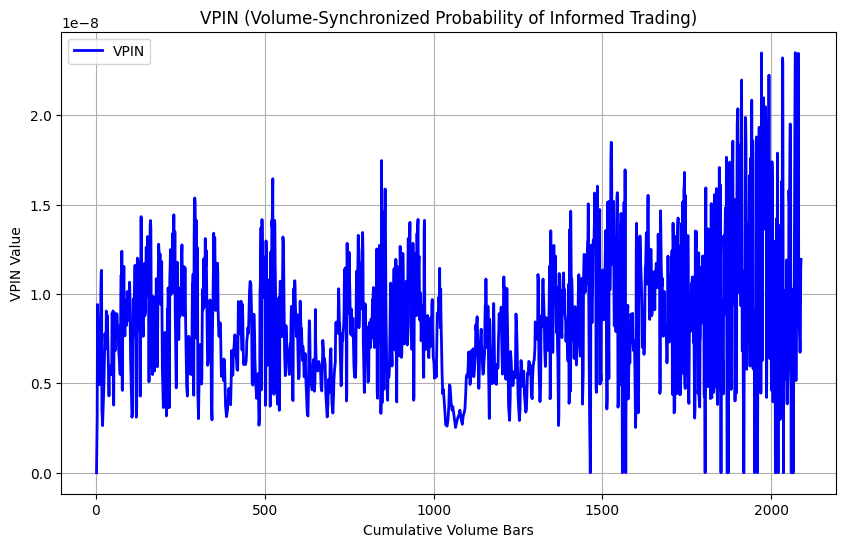

In [53]:
# Assuming 'vpin_series' contains the VPIN values
def plot_vpin(vpin_series):
    plt.figure(figsize=(10, 6))
    plt.plot(vpin_series.index, vpin_series.values, label='VPIN', color='blue', linewidth=2)
    plt.title('VPIN (Volume-Synchronized Probability of Informed Trading)')
    plt.xlabel('Cumulative Volume Bars')
    plt.ylabel('VPIN Value')
    plt.grid(True)
    plt.legend()
    plt.show()

# Call the function to plot VPIN
plot_vpin(vpin_series)